<a href="https://colab.research.google.com/github/baharifianto366/Credit_Default_Experiments/blob/main/Credit_Default_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Modern & Machine Learning
## Experiment Challenge: Credit Default Prediction

**Dataset:** Default of Credit Card Clients (UCI / Kaggle), 30.000 observasi
**Target:** `default.payment.next.month` (0 = tidak default, 1 = default)
**Metrik utama:** F1-score | **Pendukung:** Accuracy, Precision, Recall
**Evaluasi:** 5-fold Stratified CV pada training set + evaluasi pada test set

Alur: Exp 0 (Data Understanding & Preparation) → Exp 1 (Baseline) → Exp 2 (Preprocessing) → Exp 3 (Model Comparison) → Exp 4 (Hyperparameter Tuning) → Exp 5 (Advanced Model) → Final Summary.

## 0. Setup

In [1]:
%pip install -q kagglehub xgboost

Mengimpor library: pandas/numpy untuk data, matplotlib/seaborn untuk visualisasi, scikit-learn untuk pipeline, model, dan metrik. `RANDOM_STATE` dikunci supaya hasil bisa direproduksi, `TARGET` adalah nama kolom target.

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
TARGET = "default.payment.next.month"

## Experiment 0 — Data Understanding & Preparation
### 0.1 Membaca dataset
Dataset diunduh langsung dari Kaggle lewat `kagglehub` (raw, tanpa modifikasi).

In [3]:
try:
    import kagglehub
    path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")
    df = pd.read_csv(os.path.join(path, "UCI_Credit_Card.csv"))
except Exception as e:
    print("kagglehub gagal:", e, "\n-> upload file UCI_Credit_Card.csv secara manual")
    from google.colab import files
    up = files.upload()
    df = pd.read_csv(list(up.keys())[0])

df.head()

100%|██████████| 0.98M/0.98M [00:00<00:00, 22.7MB/s]

Extracting files...


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### 0.2 Dimensi, struktur, dan tipe data

Menampilkan dimensi dan tipe data tiap kolom, untuk memastikan semua kolom bertipe sesuai dan melihat jumlah non-null.

In [4]:
print("Dimensi dataset:", df.shape)
df.info()

Dimensi dataset: (30000, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BI

Statistik deskriptif (min, max, mean, dst.) untuk melihat skala tiap variabel dan nilai ekstrem.

In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.50,8660.40,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0


### 0.3 Variabel target, missing value, dan duplicate

Memeriksa missing value dan duplicate. Duplicate dicek setelah `ID` dikeluarkan karena `ID` unik di setiap baris.

In [6]:
print("Variabel target :", TARGET)
print("\nMissing value per kolom (total):", df.isna().sum().sum())
print(df.isna().sum()[df.isna().sum() > 0])

n_dup_id = df.duplicated().sum()
n_dup = df.drop(columns="ID").duplicated().sum()
print(f"\nDuplicate (semua kolom termasuk ID): {n_dup_id}")
print(f"Duplicate (setelah ID dikeluarkan)  : {n_dup}")

Variabel target : default.payment.next.month

Missing value per kolom (total): 0
Series([], dtype: int64)

Duplicate (semua kolom termasuk ID): 0
Duplicate (setelah ID dikeluarkan)  : 35


### 0.4 Nilai tidak sesuai / tidak wajar

Memeriksa nilai tidak wajar: kode kategori di luar dokumentasi (`EDUCATION`, `MARRIAGE`), nilai unik `PAY_*`, nilai negatif pada `BILL_AMT`/`PAY_AMT`, serta rentang `AGE` dan `LIMIT_BAL`.

In [7]:
# Kategori sesuai dokumentasi: SEX {1,2}; EDUCATION {1,2,3,4}; MARRIAGE {1,2,3}
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index(), "\n")

pay_cols  = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
amt_cols  = [f"PAY_AMT{i}" for i in range(1, 7)]

print("--- Nilai unik kolom PAY_* (dokumentasi: -1 s/d 9) ---")
print(pd.Series(df[pay_cols].values.ravel()).value_counts().sort_index(), "\n")

print("Jumlah BILL_AMT negatif per kolom (kelebihan bayar, masih wajar):")
print((df[bill_cols] < 0).sum().to_string())
print("\nJumlah PAY_AMT negatif:", int((df[amt_cols] < 0).sum().sum()))
print("AGE min/max:", df["AGE"].min(), "/", df["AGE"].max())
print("LIMIT_BAL min/max:", df["LIMIT_BAL"].min(), "/", df["LIMIT_BAL"].max())

--- SEX ---
SEX
1    11888
2    18112
Name: count, dtype: int64 

--- EDUCATION ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64 

--- MARRIAGE ---
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64 

--- Nilai unik kolom PAY_* (dokumentasi: -1 s/d 9) ---
-2    24415
-1    34640
 0    95919
 1     3722
 2    18964
 3     1430
 4      453
 5      137
 6       74
 7      218
 8       28
Name: count, dtype: int64 

Jumlah BILL_AMT negatif per kolom (kelebihan bayar, masih wajar):
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688

Jumlah PAY_AMT negatif: 0
AGE min/max: 21 / 79
LIMIT_BAL min/max: 10000.0 / 1000000.0


**Temuan & keputusan**:
- `EDUCATION` punya kode di luar dokumentasi (0, 5, 6) → digabung ke kategori `4 (others)` pada Exp 2.
- `MARRIAGE` punya kode `0` (tidak terdokumentasi) → digabung ke `3 (others)` pada Exp 2.
- `PAY_*` bernilai -2 dan 0 tidak ada di dokumentasi resmi, tapi pola ini umum pada dataset ini dan mengandung sinyal (status pembayaran). **Tidak dibuang**, dipertahankan sebagai fitur ordinal.
- `BILL_AMT` negatif = kelebihan bayar, nilai yang valid → dipertahankan.
- Tidak ada missing value → tidak perlu imputasi.

### 0.5 Distribusi target, predictor/target, dan train-test split

Menghitung jumlah dan persentase tiap kelas target, lalu memvisualisasikannya untuk melihat tingkat ketidakseimbangan kelas.

                            jumlah  persen
default.payment.next.month                
0                            23364   77.88
1                             6636   22.12


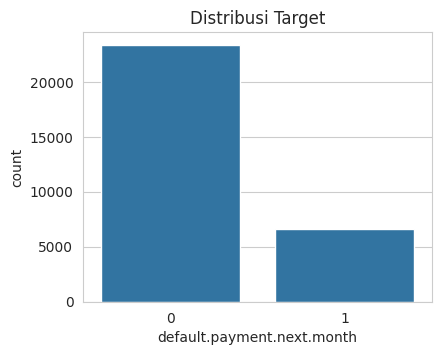

In [8]:
vc = df[TARGET].value_counts().sort_index()
print(pd.DataFrame({"jumlah": vc, "persen": (vc / len(df) * 100).round(2)}))

fig, ax = plt.subplots(figsize=(4.5, 3.5))
sns.countplot(x=TARGET, data=df, ax=ax)
ax.set_title("Distribusi Target")
plt.show()

Membuang duplicate, memisahkan predictor `X` (tanpa `ID` dan target) dari `y`, lalu train-test split 80/20 stratified. Split dilakukan sebelum preprocessing dan training agar tidak terjadi data leakage.

In [9]:
# Buang duplicate SEBELUM split (mencegah baris identik ada di train & test)
dup_mask = df.drop(columns="ID").duplicated()
print("Baris duplicate dibuang:", int(dup_mask.sum()))
df = df.loc[~dup_mask].reset_index(drop=True)

# Predictor & target (ID tidak dipakai)
X = df.drop(columns=["ID", TARGET])
y = df[TARGET]
print("Shape X:", X.shape, "| Shape y:", y.shape)

# Train-test split SEBELUM preprocessing/training, stratified karena kelas tidak seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporsi default train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))

Baris duplicate dibuang: 35
Shape X: (29965, 23) | Shape y: (29965,)
Train: (23972, 23) | Test: (5993, 23)
Proporsi default train: 0.2213 | test: 0.2213


**Keputusan Exp 0:**
1. Kelas tidak seimbang (default ± 22%) → pakai `stratify=y` saat split dan `StratifiedKFold` untuk CV, dan F1 sebagai metrik utama (accuracy menyesatkan di data imbalance).
2. Semua transformasi yang *belajar dari data* (scaler, encoder) hanya di-fit pada training fold lewat `Pipeline` → **tidak ada data leakage**.
3. Baseline (Exp 1) memakai data raw apa adanya (hanya `ID` dikeluarkan); preprocessing diterapkan di Exp 2 supaya dampaknya bisa diukur.

## Setup evaluasi
Prosedur evaluasi sama untuk semua model: 5-fold Stratified CV pada **training set** (metrik: F1), lalu fit di seluruh training set dan evaluasi pada **test set**.

Prosedur evaluasi tunggal yang dipakai semua model: 5-fold Stratified CV pada train (F1), fit pada seluruh train, lalu hitung Accuracy/Precision/Recall/F1 pada test. Hasil dikumpulkan di `results`.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []   # semua baris hasil, dipakai di tabel final

def evaluate(exp, name, est, cv_f1=None):
    """5-fold CV di train (F1) -> fit di train -> metrik di test.
    Jika cv_f1 diberikan (mis. best_score_ dari GridSearchCV), CV tidak diulang."""
    if cv_f1 is None:
        scores = cross_validate(est, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)["test_score"]
        cv_f1 = scores.mean()
        est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    row = {
        "Experiment": exp, "Model": name, "CV F1": cv_f1,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
    }
    results.append(row)
    return est, row

def show(rows):
    display(pd.DataFrame(rows).set_index(["Experiment", "Model"]).round(4))

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cms(items):
    """items = [(judul, estimator_terlatih), ...] -> confusion matrix pada TEST set."""
    fig, axes = plt.subplots(1, len(items), figsize=(4.6 * len(items), 4.2), squeeze=False)
    for ax, (title, est) in zip(axes[0], items):
        cm = confusion_matrix(y_test, est.predict(X_test))
        ConfusionMatrixDisplay(cm, display_labels=["Tidak default", "Default"]).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format="d")
        tn, fp, fn, tp = cm.ravel()
        ax.set_title(f"{title}\nTN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=9)
        ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
    plt.tight_layout(); plt.show()

## Experiment 1 — Baseline Model
Logistic Regression pada data raw (hanya `ID` dikeluarkan), tanpa scaling/encoding/penanganan imbalance.

Experiment 1: melatih Logistic Regression pada data raw (hanya `ID` yang dikeluarkan) sebagai baseline, lalu mengevaluasinya.

In [12]:
lr_base = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_base, row1 = evaluate("1", "Baseline: Logistic Regression", lr_base)
show([row1])

,,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,Model,,,,,
1,Baseline: Logistic Regression,0.3576,0.8093,0.6976,0.2436,0.3611


Confusion matrix baseline: perhatikan jumlah FN yang besar (banyak nasabah default tidak terdeteksi), sesuai Recall yang rendah.

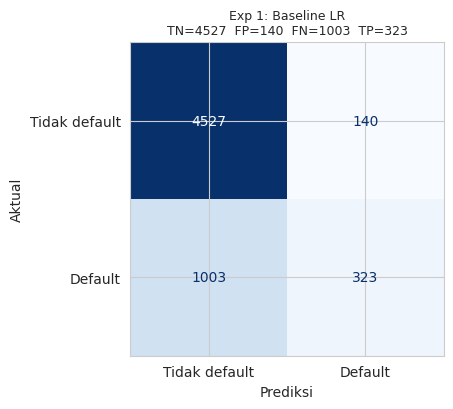

In [13]:
plot_cms([("Exp 1: Baseline LR", lr_base)])

## Experiment 2 — Preprocessing
Preprocessing yang dipilih berdasarkan temuan Exp 0:
1. **Cleaning kategori**: `EDUCATION` {0,5,6}→4 dan `MARRIAGE` {0}→3 (transformasi per-baris, tidak belajar dari data → aman dari leakage).
2. **One-Hot Encoding** untuk `SEX`, `EDUCATION`, `MARRIAGE` (nominal, bukan ordinal).
3. **StandardScaler** untuk fitur numerik (skala `LIMIT_BAL`/`BILL_AMT` jauh berbeda dengan `AGE`/`PAY_*`; penting untuk Logistic Regression).

Semuanya dibungkus `Pipeline`, jadi di-fit ulang hanya pada training fold di tiap iterasi CV.

Mendefinisikan preprocessing: cleaning kategori, One-Hot Encoding untuk `SEX`/`EDUCATION`/`MARRIAGE`, dan StandardScaler untuk fitur numerik. Semuanya dibungkus `Pipeline` sehingga hanya di-fit pada training fold.

In [14]:
CAT_COLS = ["SEX", "EDUCATION", "MARRIAGE"]
NUM_COLS = [c for c in X_train.columns if c not in CAT_COLS]

def clean_categories(X_):
    X_ = X_.copy()
    X_["EDUCATION"] = X_["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    X_["MARRIAGE"]  = X_["MARRIAGE"].replace({0: 3})
    return X_

def build_prep():
    return Pipeline([
        ("clean", FunctionTransformer(clean_categories)),
        ("encode_scale", ColumnTransformer([
            ("num", StandardScaler(), NUM_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ])),
    ])

def make_pipe(model):
    return Pipeline([("prep", build_prep()), ("model", model)])

Experiment 2: 2a = preprocessing saja, 2b = preprocessing + `class_weight='balanced'` untuk menangani imbalance. Keduanya dibandingkan dengan baseline.

In [15]:
# 2a: preprocessing murni (cleaning + encoding + scaling), model sama dengan baseline
lr_prep, row2a = evaluate("2", "Baseline + Preprocessing (LR)",
                          make_pipe(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)))

# 2b (tambahan): + class_weight='balanced' untuk menangani imbalance
lr_prep_bal, row2b = evaluate("2b (tambahan)", "LR + Preprocessing + class_weight=balanced",
                              make_pipe(LogisticRegression(max_iter=2000, class_weight="balanced",
                                                           random_state=RANDOM_STATE)))
show([row1, row2a, row2b])

,,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,Model,,,,,
1,Baseline: Logistic Regression,0.3576,0.8093,0.6976,0.2436,0.3611
2,Baseline + Preprocessing (LR),0.3576,0.8136,0.7267,0.2526,0.3749
2b (tambahan),LR + Preprocessing + class_weight=balanced,0.4778,0.6828,0.3723,0.6320,0.4685


Confusion matrix Exp 2a (preprocessing saja) dan 2b (+ class_weight). Bandingkan bagaimana FN turun dan FP naik pada 2b.

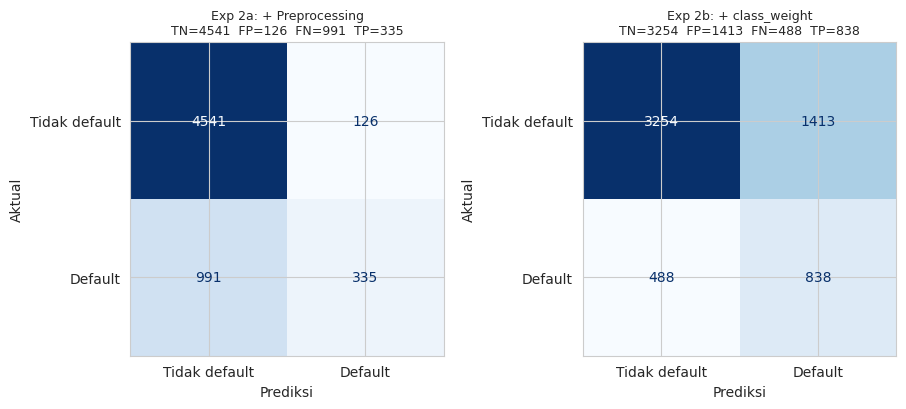

In [16]:
plot_cms([("Exp 2a: + Preprocessing", lr_prep), ("Exp 2b: + class_weight", lr_prep_bal)])

Menghitung selisih metrik terhadap baseline. Keputusan memakai `class_weight` ditentukan dari CV F1 (bukan test set) agar test set tidak ikut menentukan pilihan.

In [17]:
# Selisih terhadap baseline
cols = ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]
delta = pd.DataFrame({
    "2a - Baseline": {c: row2a[c] - row1[c] for c in cols},
    "2b - Baseline": {c: row2b[c] - row1[c] for c in cols},
}).T
display(delta.round(4))

# Keputusan data-driven (berdasarkan CV F1, bukan test) untuk eksperimen berikutnya
CLASS_WEIGHT = "balanced" if row2b["CV F1"] > row2a["CV F1"] else None
print("class_weight yang dipakai di Exp 3-5:", CLASS_WEIGHT)

,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
2a - Baseline,-0.0000,0.0043,0.0291,0.0090,0.0138
2b - Baseline,0.1202,-0.1265,-0.3253,0.3884,0.1075


class_weight yang dipakai di Exp 3-5: balanced


## Experiment 3 — Model Comparison
Logistic Regression, Decision Tree, Random Forest, semuanya dengan pipeline preprocessing yang sama dan prosedur evaluasi yang sama. Model terbaik dipilih berdasarkan **CV F1** (bukan test set, supaya test set tidak dipakai untuk memilih model).

Experiment 3: membangun Logistic Regression, Decision Tree, dan Random Forest dengan pipeline dan prosedur evaluasi yang sama. Model terbaik dipilih otomatis dari CV F1 tertinggi.

In [18]:
models3 = {
    "Logistic Regression": make_pipe(LogisticRegression(max_iter=2000, class_weight=CLASS_WEIGHT,
                                                        random_state=RANDOM_STATE)),
    "Decision Tree": make_pipe(DecisionTreeClassifier(class_weight=CLASS_WEIGHT,
                                                      random_state=RANDOM_STATE)),
    "Random Forest": make_pipe(RandomForestClassifier(n_estimators=200, class_weight=CLASS_WEIGHT,
                                                      random_state=RANDOM_STATE)),
}

rows3 = {}
for name, est in models3.items():
    models3[name], rows3[name] = evaluate("3", name, est)

show(list(rows3.values()))

best3 = max(rows3, key=lambda k: rows3[k]["CV F1"])
print("Model terbaik Exp 3 (CV F1 tertinggi):", best3)

CV F1  Test Accuracy  Test Precision  \
Experiment Model                                                        
3          Logistic Regression  0.4778         0.6828          0.3723   
           Decision Tree        0.3896         0.7258          0.3827   
           Random Forest        0.4523         0.8111          0.6418   

                                Test Recall  Test F1  
Experiment Model                                      
3          Logistic Regression       0.6320   0.4685  
           Decision Tree             0.3899   0.3863  
           Random Forest             0.3311   0.4368

Model terbaik Exp 3 (CV F1 tertinggi): Logistic Regression


Confusion matrix ketiga model Experiment 3, untuk melihat pola kesalahan masing-masing.

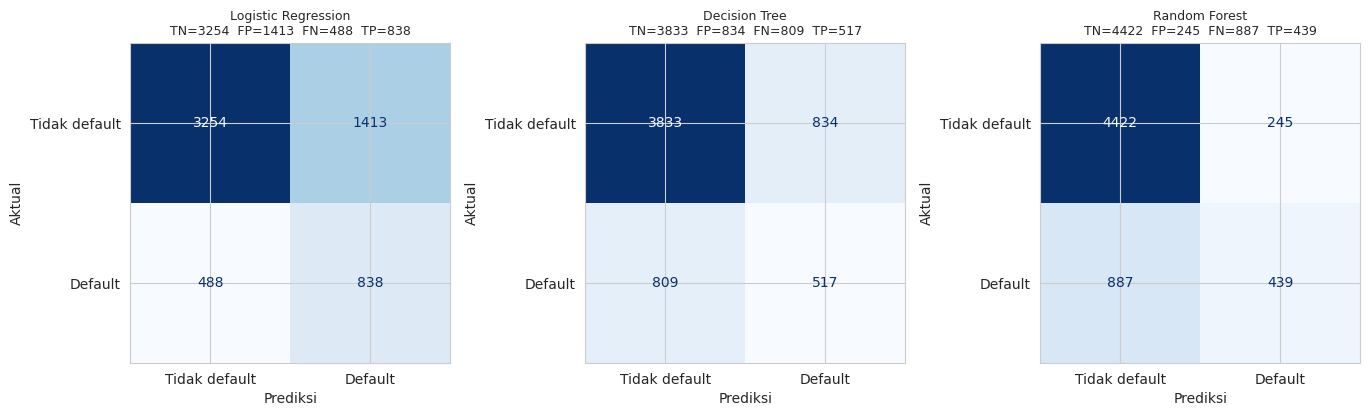

In [19]:
plot_cms([(name, models3[name]) for name in models3])

## Experiment 4 — Hyperparameter Tuning
`GridSearchCV` (5-fold, `scoring='f1'`) pada model terbaik Exp 3. Grid disesuaikan dengan model yang terpilih.

Mendefinisikan grid hyperparameter untuk tiap kandidat model. Yang dipakai hanya grid milik model terbaik dari Experiment 3.

In [20]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear"],
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 10, 50, 100],
        "model__criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "model__n_estimators": [200],
        "model__max_depth": [6, 10, None],
        "model__min_samples_leaf": [1, 5, 10],
        "model__max_features": ["sqrt", 0.5],
    },
}
grid = param_grids[best3]
print("Model        :", best3)
print("Grid yang diuji:")
for k, v in grid.items():
    print(f"  {k}: {v}")

Model        : Logistic Regression
Grid yang diuji:
  model__C: [0.01, 0.1, 1, 10, 100]
  model__penalty: ['l1', 'l2']
  model__solver: ['liblinear']


Experiment 4: GridSearchCV 5-fold dengan scoring F1. Kombinasi terbaik otomatis di-refit pada seluruh train lalu dievaluasi pada test.

In [21]:
gs = GridSearchCV(clone(models3[best3]), grid, scoring="f1", cv=cv, n_jobs=-1, refit=True, verbose=1)
gs.fit(X_train, y_train)

print("Kombinasi terbaik :", gs.best_params_)
print("Best CV F1-score  :", round(gs.best_score_, 4))

tuned, row4 = evaluate("4", f"Tuned {best3}", gs.best_estimator_, cv_f1=gs.best_score_)
show([rows3[best3], row4])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Kombinasi terbaik : {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'liblinear'}
Best CV F1-score  : 0.4794


,,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,Model,,,,,
3,Logistic Regression,0.4778,0.6828,0.3723,0.6320,0.4685
4,Tuned Logistic Regression,0.4794,0.6856,0.3753,0.6335,0.4714


Membandingkan performa sebelum vs sesudah tuning dalam satu tabel beserta selisihnya.

In [22]:
before, after = rows3[best3], row4
cmp = pd.DataFrame({
    "Sebelum tuning": {c: before[c] for c in cols},
    "Setelah tuning": {c: after[c] for c in cols},
})
cmp["Selisih"] = cmp["Setelah tuning"] - cmp["Sebelum tuning"]
display(cmp.round(4))

,Sebelum tuning,Setelah tuning,Selisih
CV F1,0.4778,0.4794,0.0016
Test Accuracy,0.6828,0.6856,0.0028
Test Precision,0.3723,0.3753,0.0031
Test Recall,0.6320,0.6335,0.0015
Test F1,0.4685,0.4714,0.0028


Confusion matrix sebelum vs sesudah tuning, untuk melihat apakah pola kesalahan benar-benar berubah.

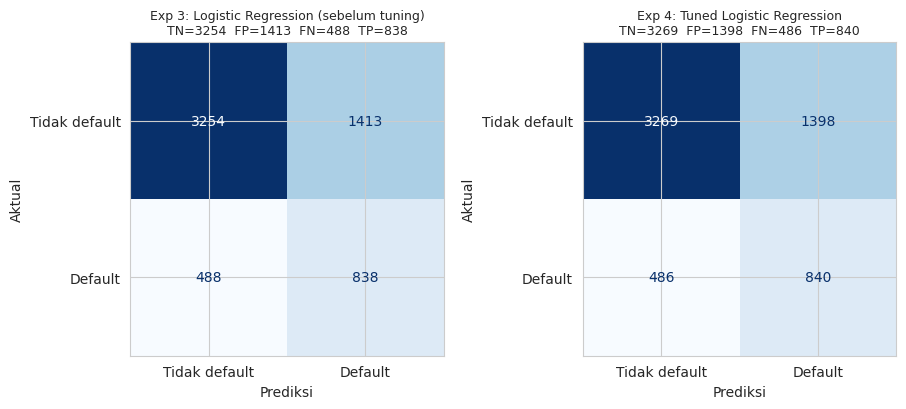

In [23]:
plot_cms([(f"Exp 3: {best3} (sebelum tuning)", models3[best3]), (f"Exp 4: Tuned {best3}", tuned)])

## Experiment 5 — Advanced Model
**XGBoost** (boosting berbasis gradient). Prosedur evaluasi sama (5-fold CV di train + test set). Hyperparameter memakai konfigurasi standar yang konservatif (belum di-tuning), jadi catat ini saat membandingkan dengan model tuned di Exp 4.

Experiment 5: melatih XGBoost. `scale_pos_weight` (rasio kelas negatif/positif) adalah padanan `class_weight='balanced'` untuk XGBoost.

In [24]:
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos if CLASS_WEIGHT == "balanced" else 1.0   # padanan class_weight untuk XGBoost

xgb = make_pipe(XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="logloss",
    random_state=RANDOM_STATE, n_jobs=1,
))
xgb, row5 = evaluate("5", "XGBoost", xgb)
show([row4, row5])

,,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
Experiment,Model,,,,,
4,Tuned Logistic Regression,0.4794,0.6856,0.3753,0.6335,0.4714
5,XGBoost,0.5385,0.7565,0.4630,0.6275,0.5328


Membandingkan XGBoost dengan model tuned dari Experiment 4 beserta selisih tiap metrik.

In [25]:
d5 = pd.DataFrame({
    f"Exp 4 ({row4['Model']})": {c: row4[c] for c in cols},
    "Exp 5 (XGBoost)": {c: row5[c] for c in cols},
})
d5["Selisih (5 - 4)"] = d5.iloc[:, 1] - d5.iloc[:, 0]
display(d5.round(4))

,Exp 4 (Tuned Logistic Regression),Exp 5 (XGBoost),Selisih (5 - 4)
CV F1,0.4794,0.5385,0.0591
Test Accuracy,0.6856,0.7565,0.0709
Test Precision,0.3753,0.4630,0.0877
Test Recall,0.6335,0.6275,-0.0060
Test F1,0.4714,0.5328,0.0614


Confusion matrix model tuned (Exp 4) vs XGBoost (Exp 5), melihat dari mana peningkatan F1 berasal (FP, FN, atau keduanya).

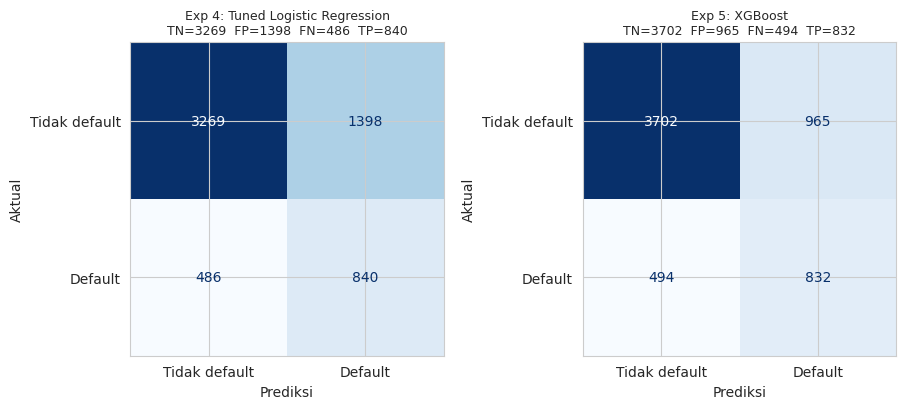

In [26]:
plot_cms([(f"Exp 4: Tuned {best3}", tuned), ("Exp 5: XGBoost", xgb)])

## Final Summary


In [27]:
summary = pd.DataFrame(results)
summary["Experiment"] = summary["Experiment"].map({
    "1": "1 - Baseline", "2": "2 - Baseline + Preprocessing",
    "2b (tambahan)": "2b - Tambahan (class_weight)",
    "3": "3 - Model Comparison", "4": "4 - Tuned Model", "5": "5 - Advanced Model",
})
summary = summary.round(4)
display(summary)
summary.to_csv("hasil_ringkasan_eksperimen.csv", index=False)

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1 - Baseline,Baseline: Logistic Regression,0.3576,0.8093,0.6976,0.2436,0.3611
1,2 - Baseline + Preprocessing,Baseline + Preprocessing (LR),0.3576,0.8136,0.7267,0.2526,0.3749
2,2b - Tambahan (class_weight),LR + Preprocessing + class_weight=balanced,0.4778,0.6828,0.3723,0.6320,0.4685
3,3 - Model Comparison,Logistic Regression,0.4778,0.6828,0.3723,0.6320,0.4685
4,3 - Model Comparison,Decision Tree,0.3896,0.7258,0.3827,0.3899,0.3863
5,3 - Model Comparison,Random Forest,0.4523,0.8111,0.6418,0.3311,0.4368
6,4 - Tuned Model,Tuned Logistic Regression,0.4794,0.6856,0.3753,0.6335,0.4714
7,5 - Advanced Model,XGBoost,0.5385,0.7565,0.4630,0.6275,0.5328


Grafik batang CV F1 vs Test F1 tiap eksperimen untuk melihat tren dan konsistensi antara CV dan test.

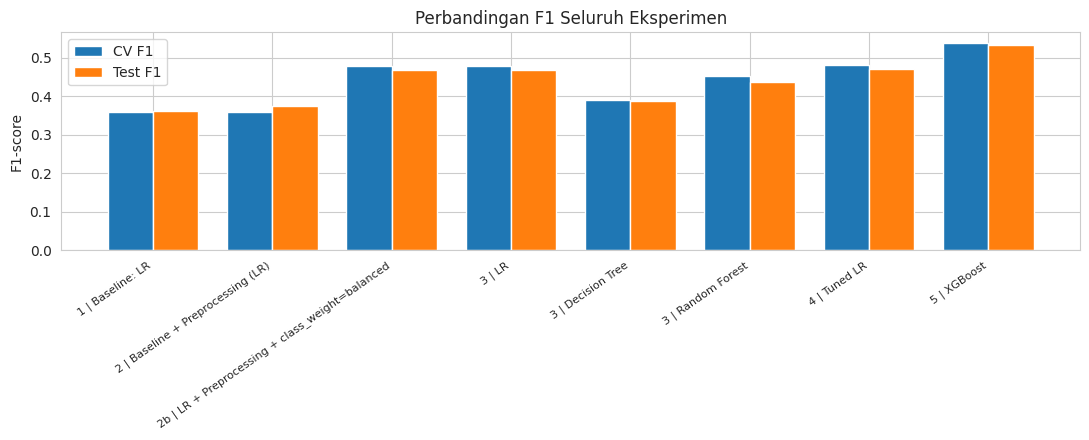

In [28]:
# Visualisasi F1 per eksperimen
plot_df = summary.copy()
plot_df["label"] = plot_df["Experiment"].str.split(" - ").str[0] + " | " + plot_df["Model"].str.replace("Logistic Regression", "LR")
x = np.arange(len(plot_df)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - w/2, plot_df["CV F1"], w, label="CV F1")
ax.bar(x + w/2, plot_df["Test F1"], w, label="Test F1")
ax.set_xticks(x); ax.set_xticklabels(plot_df["label"], rotation=35, ha="right", fontsize=8)
ax.set_ylabel("F1-score"); ax.set_title("Perbandingan F1 Seluruh Eksperimen"); ax.legend()
plt.tight_layout(); plt.show()

### Pemilihan model final
Kriteria: **CV F1 tertinggi** (stabil, tidak menyentuh test set), dengan Test F1 sebagai konfirmasi. Jika selisih antar model sangat kecil (di bawah standar deviasi CV), pilih model yang lebih sederhana.

Mengurutkan model berdasarkan CV F1 untuk menentukan kandidat model final.

In [29]:
main = summary[~summary["Experiment"].str.startswith("2b")]
cand = main.sort_values("CV F1", ascending=False)
display(cand[["Experiment", "Model", "CV F1", "Test F1"]].head(5))
print("Kandidat model final (CV F1 tertinggi):", cand.iloc[0]["Model"], "| CV F1 =", cand.iloc[0]["CV F1"])

,Experiment,Model,CV F1,Test F1
7,5 - Advanced Model,XGBoost,0.5385,0.5328
6,4 - Tuned Model,Tuned Logistic Regression,0.4794,0.4714
3,3 - Model Comparison,Logistic Regression,0.4778,0.4685
5,3 - Model Comparison,Random Forest,0.4523,0.4368
4,3 - Model Comparison,Decision Tree,0.3896,0.3863


Kandidat model final (CV F1 tertinggi): XGBoost | CV F1 = 0.5385


Confusion matrix model final (CV F1 tertinggi), dalam jumlah dan dalam persentase per kelas aktual, beserta rincian TN/FP/FN/TP.

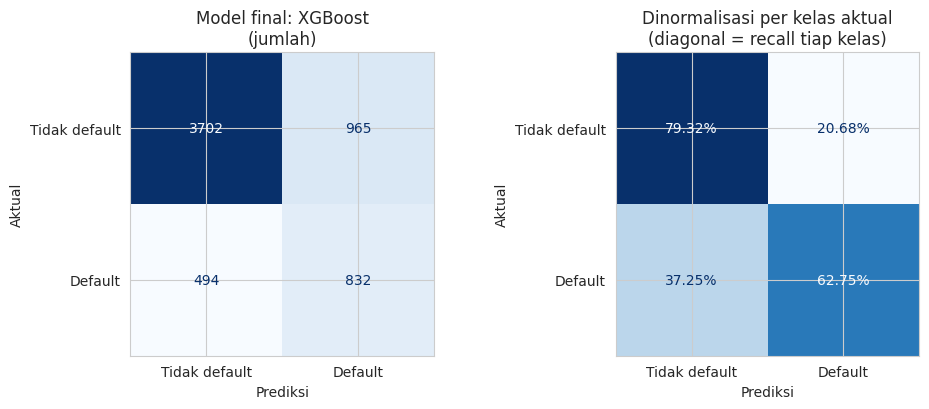

TN=3702 | FP=965 | FN=494 | TP=832
Dari 1326 nasabah yang sebenarnya default, 832 terdeteksi (62.7%) dan 494 lolos.
Dari 1797 nasabah yang diprediksi default, 832 benar (46.3%) dan 965 salah alarm.


In [30]:
fitted = {
    "Baseline: Logistic Regression": lr_base,
    "Baseline + Preprocessing (LR)": lr_prep,
    "LR + Preprocessing + class_weight=balanced": lr_prep_bal,
    **models3,
    f"Tuned {best3}": tuned,
    "XGBoost": xgb,
}
final_name = cand.iloc[0]["Model"]
final_est = fitted[final_name]
y_pred_final = final_est.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["Tidak default", "Default"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Model final: {final_name}\n(jumlah)")
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final, normalize="true", display_labels=["Tidak default", "Default"],
    cmap="Blues", colorbar=False, values_format=".2%", ax=axes[1])
axes[1].set_title("Dinormalisasi per kelas aktual\n(diagonal = recall tiap kelas)")
for ax in axes: ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
plt.tight_layout(); plt.show()

print(f"TN={tn} | FP={fp} | FN={fn} | TP={tp}")
print(f"Dari {fn + tp} nasabah yang sebenarnya default, {tp} terdeteksi ({tp/(tp+fn):.1%}) dan {fn} lolos.")
print(f"Dari {fp + tp} nasabah yang diprediksi default, {tp} benar ({tp/(tp+fp):.1%}) dan {fp} salah alarm.")